In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import RFE, mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

In [2]:
# Load and inspect dataset
df = pd.read_csv('clean_data.csv')
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData description:")
print(df.describe())
print("\nData info:")
print(df.info())

Dataset shape: (534, 7)

First 5 rows:
   PCOS (Y/N)  Follicle No.(R)  Follicle No.(L)  Skin darkening(Y/N)  \
0           0                3                3                    0   
1           0                5                3                    0   
2           1               15               13                    0   
3           0                2                2                    0   
4           0                4                3                    0   

   hair growth(Y/N)  Weight gain(Y/N)  Cycle(R/I)  
0                 0                 0           2  
1                 0                 0           2  
2                 0                 0           2  
3                 0                 0           2  
4                 0                 0           2  

Data description:
       PCOS (Y/N)  Follicle No.(R)  Follicle No.(L)  Skin darkening(Y/N)  \
count  534.000000       534.000000       534.000000           534.000000   
mean     0.323970         6.619850         6.

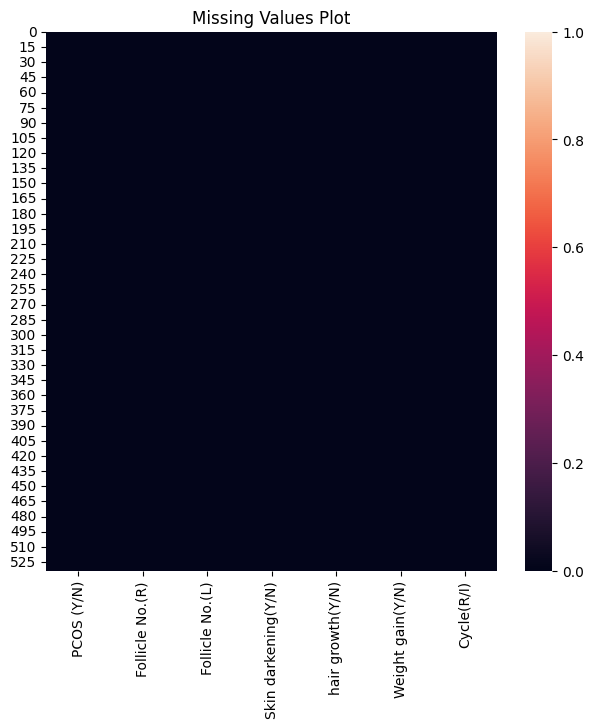

In [3]:
def plot_missing_vals(data: pd.DataFrame) -> None:
    '''for plotting missing values'''
    plt.figure(figsize = (16,7))
    plt.subplot(1,2,1)
    sns.heatmap(df.isnull(), cbar = True, vmin=0, vmax=1)
    plt.title("Missing Values Plot")
    plt.show()
    
plot_missing_vals(df)

In [4]:
# Handle missing values
df.fillna(df.mean(), inplace=True)
print("\nData description after handing missing values:")
df.describe()


Data description after handing missing values:


,PCOS (Y/N),Follicle No.(R),Follicle No.(L),Skin darkening(Y/N),hair growth(Y/N),Weight gain(Y/N),Cycle(R/I)
count,534.000000,534.000000,534.000000,534.000000,534.000000,534.000000,534.000000
mean,0.323970,6.619850,6.112360,0.305243,0.277154,0.374532,2.559925
std,0.468428,4.441791,4.245129,0.460942,0.448013,0.484456,0.901929
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,2.000000
50%,0.000000,6.000000,5.000000,0.000000,0.000000,0.000000,2.000000
75%,1.000000,10.000000,8.750000,1.000000,1.000000,1.000000,4.000000
max,1.000000,20.000000,22.000000,1.000000,1.000000,1.000000,5.000000


In [5]:
target = 'PCOS (Y/N)'
all_features = list(df.columns[1:])

features_df = df[all_features]
binary_features = features_df.columns[(features_df.max() == 1) & (features_df.min() == 0)]
print('Target: ', target)
print('Features:', all_features)
print('binary features : ', binary_features)

labelencoder = LabelEncoder()
df[target] = labelencoder.fit_transform(df[target])

Target:  PCOS (Y/N)
Features: ['Follicle No.(R)', 'Follicle No.(L)', 'Skin darkening(Y/N)', 'hair growth(Y/N)', 'Weight gain(Y/N)', 'Cycle(R/I)']
binary features :  Index(['Skin darkening(Y/N)', 'hair growth(Y/N)', 'Weight gain(Y/N)'], dtype='object')


In [6]:
# Prepare features and target
X = df.drop(target, axis=1)
y = df[target]

# Identify binary features
binary_features = [col for col in X.columns if set(X[col].unique()) == {0, 1}]
print("\nBinary features:", binary_features)
binary_data = features_df[binary_features]

df.info()


Binary features: ['Skin darkening(Y/N)', 'hair growth(Y/N)', 'Weight gain(Y/N)']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 534 entries, 0 to 533
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   PCOS (Y/N)           534 non-null    int64
 1   Follicle No.(R)      534 non-null    int64
 2   Follicle No.(L)      534 non-null    int64
 3   Skin darkening(Y/N)  534 non-null    int64
 4   hair growth(Y/N)     534 non-null    int64
 5   Weight gain(Y/N)     534 non-null    int64
 6   Cycle(R/I)           534 non-null    int64
dtypes: int64(7)
memory usage: 29.3 KB


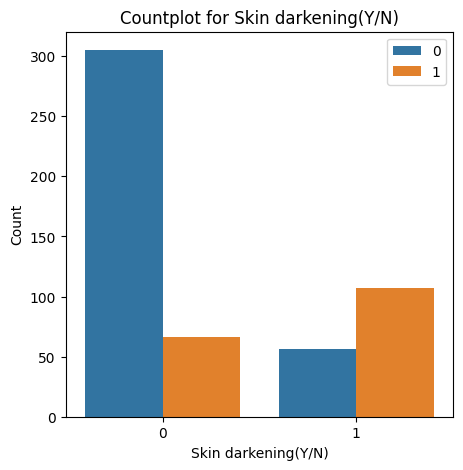

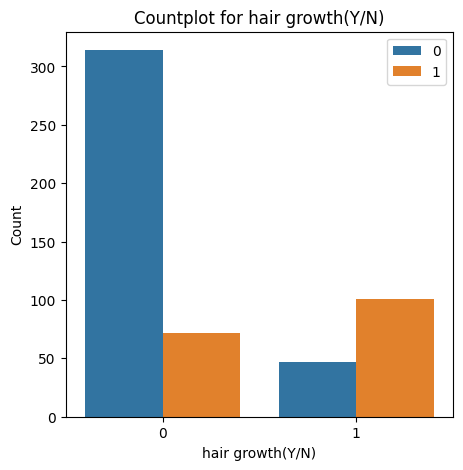

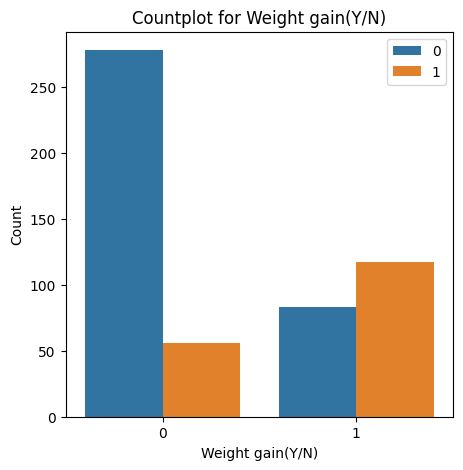

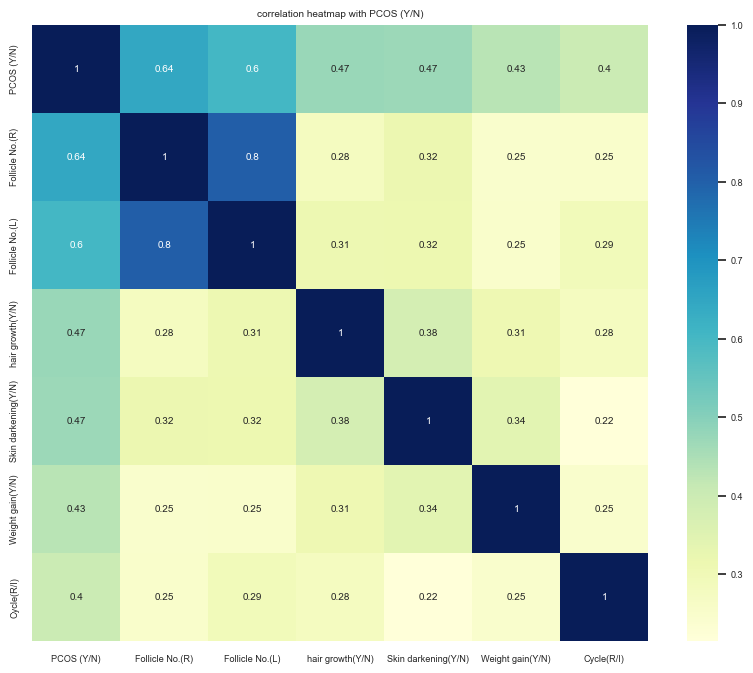

In [7]:
def create_countplots(df, features, target) -> None:
    for feature in features:
        plt.figure(figsize=(5,5))
        sns.countplot(data=df, x=feature,hue=target)
        plt.xlabel(feature)
        plt.ylabel('Count')
        plt.legend()
        plt.title(f"Countplot for {feature}")
        plt.show()
        
create_countplots(df, binary_features, target)

corr_matrix = df.corr().abs()
corr_matrix[target].sort_values()

plt.figure(figsize=(10,8))
sns.set(font_scale=0.6)
indexes = corr_matrix.nlargest(17, target)[target].index
cm = pd.DataFrame(np.corrcoef(df[indexes].values.T))
sns.heatmap(data = cm, annot = True, yticklabels = indexes.values,
            xticklabels = indexes.values, cbar =True, cmap = 'YlGnBu',
            square = True)
plt.title(f"correlation heatmap with {target}")
plt.show()

In [8]:
#Encode categorical variables
labelencoder = LabelEncoder()
df['PCOS (Y/N)'] = labelencoder.fit_transform(df['PCOS (Y/N)'])

# Prepare features and target
X = df.drop('PCOS (Y/N)', axis=1)
y = df['PCOS (Y/N)']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train models and evaluate to find the best one
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

best_model = None
best_accuracy = 0
model_performance = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    model_performance[name] = accuracy
    
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model
        best_model_name = name

print("\nModel Performance Comparison:")
for name, acc in model_performance.items():
    print(f"{name}: {acc:.4f}")
print(f"\nBest model is {best_model_name} with accuracy {best_accuracy:.4f}")


Model Performance Comparison:
Random Forest: 0.8598
Logistic Regression: 0.8785
Naive Bayes: 0.9065
Decision Tree: 0.8598

Best model is Naive Bayes with accuracy 0.9065



Random Forest Performance:
Accuracy: 0.8598130841121495
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.89      0.90        75
           1       0.76      0.78      0.77        32

    accuracy                           0.86       107
   macro avg       0.83      0.84      0.83       107
weighted avg       0.86      0.86      0.86       107



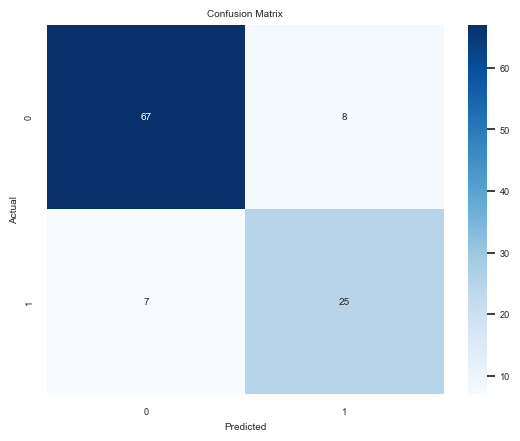


Logistic Regression Performance:
Accuracy: 0.8785046728971962
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.92      0.91        75
           1       0.81      0.78      0.79        32

    accuracy                           0.88       107
   macro avg       0.86      0.85      0.85       107
weighted avg       0.88      0.88      0.88       107



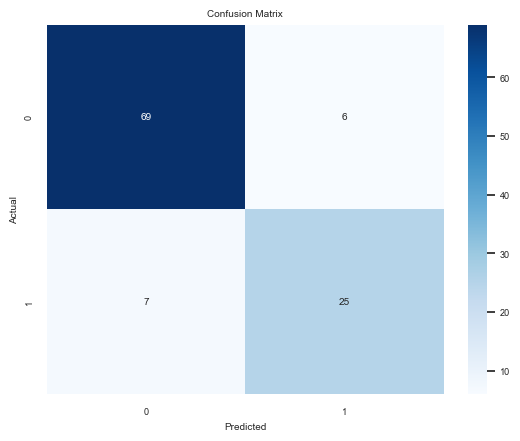


Naive Bayes Performance:
Accuracy: 0.9065420560747663
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.91      0.93        75
           1       0.81      0.91      0.85        32

    accuracy                           0.91       107
   macro avg       0.88      0.91      0.89       107
weighted avg       0.91      0.91      0.91       107



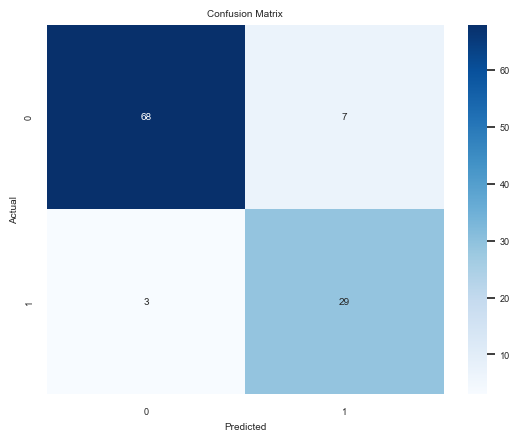


Decision Tree Performance:
Accuracy: 0.8598130841121495
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.89      0.90        75
           1       0.76      0.78      0.77        32

    accuracy                           0.86       107
   macro avg       0.83      0.84      0.83       107
weighted avg       0.86      0.86      0.86       107



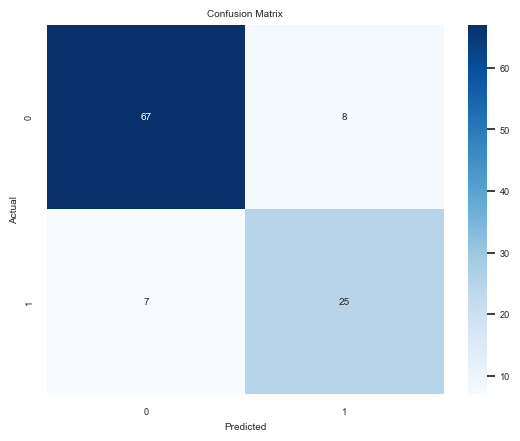

In [9]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

print("\nRandom Forest Performance:")
evaluate_model(models['Random Forest'], X_test_scaled, y_test)

print("\nLogistic Regression Performance:")
evaluate_model(models['Logistic Regression'], X_test_scaled, y_test)

print("\nNaive Bayes Performance:")
evaluate_model(models['Naive Bayes'], X_test_scaled, y_test)

print("\nDecision Tree Performance:")
evaluate_model(models['Decision Tree'], X_test_scaled, y_test)

# Save the best model and scaler
with open('pcos_best_model.pkl','wb') as file:
    pickle.dump(best_model, file)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

features selected by lr:  Index(['Skin darkening(Y/N)', 'hair growth(Y/N)', 'Weight gain(Y/N)',
       'Cycle(R/I)'],
      dtype='object')


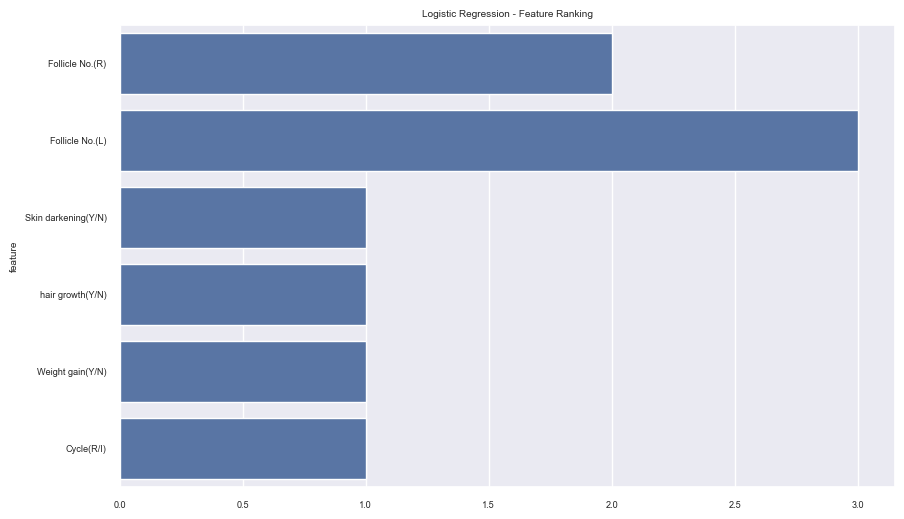

features selected by rfc:  Index(['Follicle No.(R)', 'Follicle No.(L)', 'Skin darkening(Y/N)',
       'hair growth(Y/N)'],
      dtype='object')


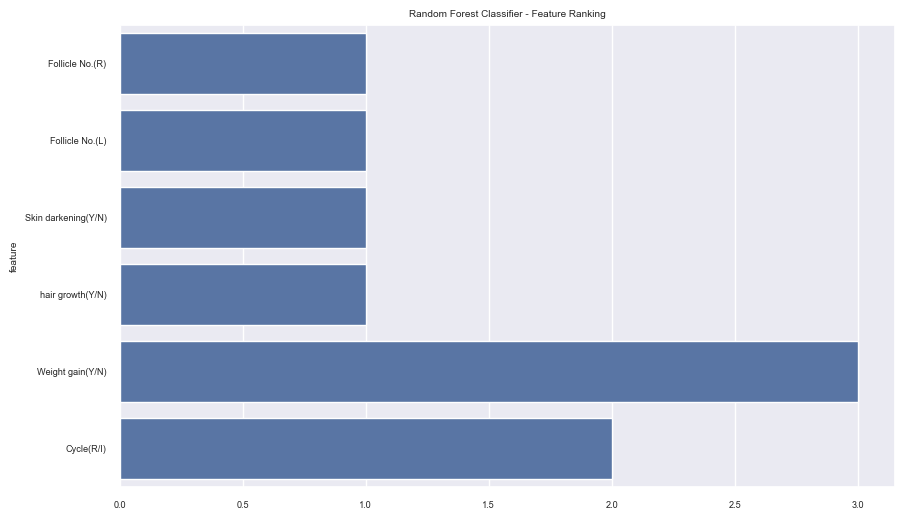

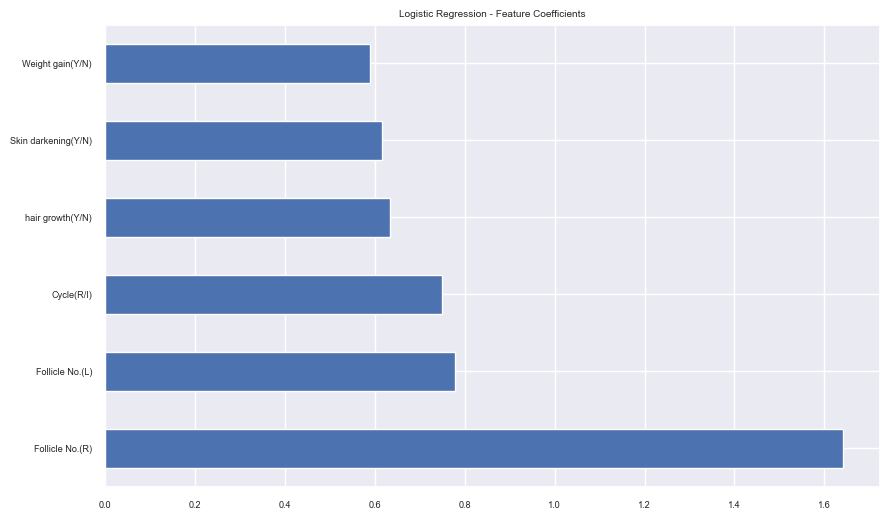

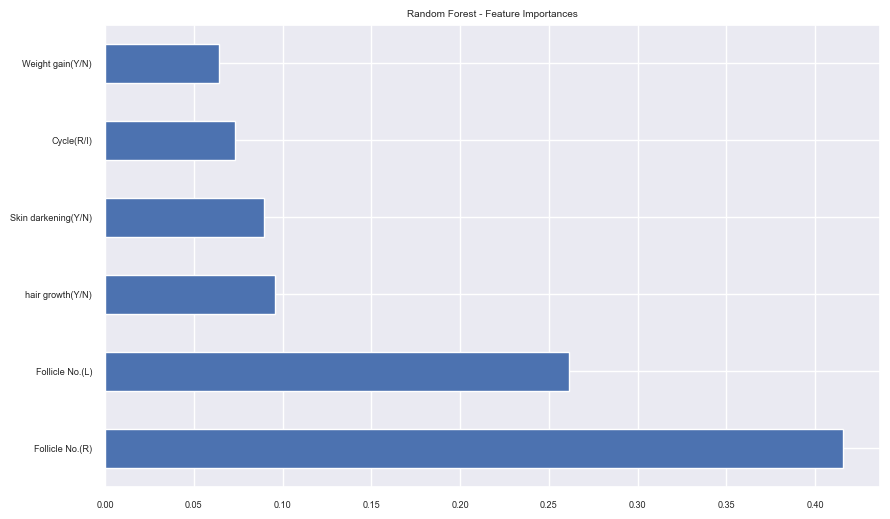

In [10]:
# RFE (original)
rfe_lr = RFE(models['Logistic Regression'], n_features_to_select=4)
rfe_rfc = RFE(models['Random Forest'], n_features_to_select=4)

# Logistic regression RFE
x_train_rfe_lr = rfe_lr.fit_transform(X_train, y_train)
features_lr_indices = [i for i, value in enumerate(rfe_lr.support_) if value]
features_lr = features_df.columns[features_lr_indices]
print("features selected by lr: ", features_lr)

plt.figure(figsize=(10,6))
sns.barplot(x=rfe_lr.ranking_, y=features_df.columns)
plt.title('Logistic Regression - Feature Ranking')
plt.ylabel("feature")
plt.show()

# Random Forest RFE
x_train_rfe_rfc = rfe_rfc.fit_transform(X_train, y_train)
features_rfc_indices = [i for i, value in enumerate(rfe_rfc.support_) if value]
features_rfc = features_df.columns[features_rfc_indices]
print("features selected by rfc: ", features_rfc)

plt.figure(figsize=(10,6))
sns.barplot(x=rfe_rfc.ranking_, y=features_df.columns)
plt.title('Random Forest Classifier - Feature Ranking')
plt.ylabel("feature")
plt.show()

# Feature importance plots (corrected original)
plt.figure(figsize=(10,6))
lr_coef = pd.Series(np.abs(models['Logistic Regression'].coef_[0]), index=X.columns)
lr_coef.nlargest(15).plot(kind='barh')
plt.title('Logistic Regression - Feature Coefficients')
plt.show()

plt.figure(figsize=(10,6))
rf_importances = pd.Series(models['Random Forest'].feature_importances_, index=X.columns)
rf_importances.nlargest(15).plot(kind='barh')
plt.title('Random Forest - Feature Importances')
plt.show()

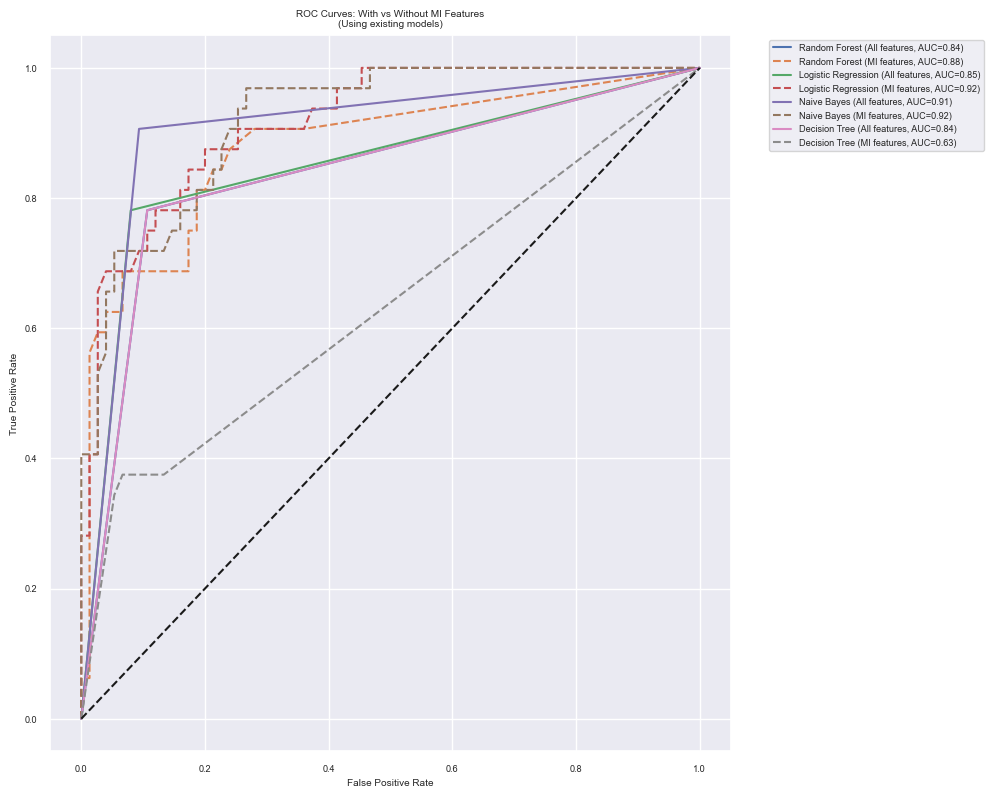

In [11]:
# Corrected MI comparison function
def plot_MI_comparison(models, X_test_scaled, y_test):
    mi_scores = mutual_info_classif(X_train_scaled, y_train)
    mi_mask = mi_scores > np.median(mi_scores)
    
    # Create full feature version of MI-selected data (padding with zeros)
    X_test_mi_full = np.zeros_like(X_test_scaled)
    X_test_mi_full[:, mi_mask] = X_test_scaled[:, mi_mask]
    
    plt.figure(figsize=(10,8))
    
    for name, model in models.items():
        # Original predictions
        y_pred = model.predict(X_test_scaled)
        fpr, tpr, _ = roc_curve(y_test, y_pred)
        auc = roc_auc_score(y_test, y_pred)
        plt.plot(fpr, tpr, label=f'{name} (All features, AUC={auc:.2f})')
        
        # MI-feature predictions using padded data
        if hasattr(model, 'predict_proba'):
            y_pred_mi = model.predict_proba(X_test_mi_full)[:, 1]
        else:
            y_pred_mi = model.predict(X_test_mi_full)
            
        fpr_mi, tpr_mi, _ = roc_curve(y_test, y_pred_mi)
        auc_mi = roc_auc_score(y_test, y_pred_mi)
        plt.plot(fpr_mi, tpr_mi, '--', label=f'{name} (MI features, AUC={auc_mi:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves: With vs Without MI Features\n(Using existing models)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Run comparison with all models
plot_MI_comparison(models, X_test_scaled, y_test)

In [13]:
#Original user input function
def get_user_input():
    print("Please enter the following information:")
    features = {
        'Follicle No.(R)': float(input("Follicle No. (Right): ")),
        'Follicle No.(L)': float(input("Follicle No. (Left): ")),
        'Skin darkening(Y/N)': float(input("Skin darkening (0 for No, 1 for Yes): ")),
        'hair growth(Y/N)': float(input("Hair growth (0 for No, 1 for Yes): ")),
        'Weight gain(Y/N)': float(input("Weight gain (0 for No, 1 for Yes): ")),
        'Cycle(R/I)': float(input("Cycle regularity: "))
    }
    
    for col in X.columns:
        if col not in features:
            features[col] = 0
            
    return pd.DataFrame([features], columns=X.columns)
    
# Prediction using the best model
try:
    user_data = get_user_input()
    user_data_scaled = scaler.transform(user_data)
    prediction = best_model.predict(user_data_scaled)
    
    print(f"\nPrediction Result (using {best_model_name}):")
    if prediction[0] == 1:
        print("The model predicts PCOS is likely.")
    else:
        print("The model predicts PCOS is unlikely.")
        
except Exception as e:
    print(f"An error occurred: {e}")

Please enter the following information:


Follicle No. (Right):  21
Follicle No. (Left):  20
Skin darkening (0 for No, 1 for Yes):  1
Hair growth (0 for No, 1 for Yes):  1
Weight gain (0 for No, 1 for Yes):  1
Cycle regularity:  4



Prediction Result (using Naive Bayes):
The model predicts PCOS is likely.
